In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ----------------------------------------------------------------------------
# Paths (inputs in ./data/wind_uv, outputs in ./publish)
# NOTE: VS Code notebooks sometimes run with CWD = workspace root.
#       The fallback below makes paths work whether CWD is Fig6/ or its parent.
# ----------------------------------------------------------------------------
FIG_DIR = Path("Fig6") if Path("Fig6").is_dir() else Path(".")
DATA_DIR = FIG_DIR / "data" / "wind_uv"
OUT_DIR = FIG_DIR / "publish"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OBS_DIR = DATA_DIR / "results_uv_obs"
SIM_DIR = DATA_DIR / "results_uv_sim"

_required = [OBS_DIR / "u_obs.csv", OBS_DIR / "v_obs.csv", SIM_DIR]
_missing = [p for p in _required if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "Missing required input(s):\n" + "\n".join(f"- {p.as_posix()}" for p in _missing)
    )

# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------
TS_COL = "timestamp_utc"
TS_FORMAT = "%Y%m%d %H%M"  # e.g., '20250923 1900'

# Requested time window (UTC, inclusive)
START_TIME = pd.Timestamp("2025-09-23 19:00", tz="UTC")
END_TIME = pd.Timestamp("2025-09-24 01:00", tz="UTC")
WINDOW_TAG = f"{START_TIME:%Y%m%d-%H}_to_{END_TIME:%Y%m%d-%H}"

# Only 24h forecast time
LEAD = "24h"

# ERA5-driven cases only
CASE_ORDER = [
    "era5_no_lcz_no_srtm",  # low-res terrain + low-res LCZ
    "era5_no_lcz",  # hi-res terrain + low-res LCZ
    "era5",  # hi-res terrain + hi-res LCZ
]

CASE_META = {
    "era5_no_lcz_no_srtm": {
        "label": "Low terrain\nLow LCZ",
        "color": "#9E9E9E",
    },
    "era5_no_lcz": {
        "label": "High terrain\nLow LCZ",
        "color": "#6E8BC3",
    },
    "era5": {
        "label": "High terrain\nHigh LCZ",
        "color": "#C96A5A",
    },
}

# ----------------------------------------------------------------------------
# Plot style (match Fig4/02_rmse_all_stations as much as possible)
# ----------------------------------------------------------------------------
_avail_fonts = {f.name for f in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in _avail_fonts else "DejaVu Sans"

mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.sans-serif": [FONT_FAMILY],
        "font.size": 16,
    }
)

print("[Paths] DATA_DIR:", DATA_DIR.resolve())
print("[Paths] OUT_DIR :", OUT_DIR.resolve())
print("[Config] Window:", START_TIME, "to", END_TIME, "UTC")
print("[Config] Lead  :", LEAD)
print("[Config] Cases :", ", ".join(CASE_ORDER))
print("[Font] Using   :", FONT_FAMILY)

[Paths] DATA_DIR: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\data\wind_uv
[Paths] OUT_DIR : E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish
[Config] Window: 2025-09-23 19:00:00+00:00 to 2025-09-24 01:00:00+00:00 UTC
[Config] Lead  : 24h
[Config] Cases : era5_no_lcz_no_srtm, era5_no_lcz, era5
[Font] Using   : Arial


In [3]:
# ----------------------------------------------------------------------------
# Helpers: IO, parsing, VRMSE, saving
# ----------------------------------------------------------------------------


def save_tiff(fig: "plt.Figure", out_path: Path, dpi: int = 600) -> None:
    """Save a TIFF; tries LZW compression if supported."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    common = dict(dpi=dpi, format="tiff", bbox_inches="tight")
    try:
        fig.savefig(out_path, pil_kwargs={"compression": "tiff_lzw"}, **common)
    except TypeError:
        fig.savefig(out_path, **common)


def read_uv_obs(component: str) -> pd.DataFrame:
    path = OBS_DIR / f"{component}_obs.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing obs file: {path.as_posix()}")
    return pd.read_csv(path, dtype={TS_COL: str})


def read_uv_sim(case_key: str, component: str, lead: str) -> pd.DataFrame:
    path = SIM_DIR / f"{case_key}_{component}_sim_{lead}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing sim file: {path.as_posix()}")
    return pd.read_csv(path, dtype={TS_COL: str})


def parse_and_subset(
    df: pd.DataFrame,
    stations: list[str],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    ts_col: str = TS_COL,
    ts_format: str = TS_FORMAT,
) -> pd.DataFrame:
    """Parse timestamps, subset to time window, and coerce station columns to numeric."""
    required_cols = [ts_col, *stations]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[required_cols].copy()
    data[ts_col] = data[ts_col].astype(str).str.strip()
    data[ts_col] = pd.to_datetime(data[ts_col], format=ts_format, utc=True, errors="coerce")
    data = data.dropna(subset=[ts_col])

    mask = (data[ts_col] >= start_time) & (data[ts_col] <= end_time)
    data = data.loc[mask].sort_values(ts_col).reset_index(drop=True)

    data[stations] = data[stations].apply(pd.to_numeric, errors="coerce")
    return data


def vector_rmse_by_station(
    obs_u_df: pd.DataFrame,
    obs_v_df: pd.DataFrame,
    sim_u_df: pd.DataFrame,
    sim_v_df: pd.DataFrame,
    stations: list[str],
    ts_col: str = TS_COL,
) -> tuple[pd.Series, int]:
    """Vector RMSE per station: sqrt(mean(du^2 + dv^2)) over common timestamps."""
    obs_u = obs_u_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    obs_v = obs_v_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_u = sim_u_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_v = sim_v_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)

    common = obs_u.index
    common = common.intersection(obs_v.index)
    common = common.intersection(sim_u.index)
    common = common.intersection(sim_v.index)

    if len(common) == 0:
        out = pd.Series(index=stations, dtype=float, name="vrmse")
        return out, 0

    du = sim_u.loc[common, stations] - obs_u.loc[common, stations]
    dv = sim_v.loc[common, stations] - obs_v.loc[common, stations]

    vrmse = np.sqrt((du**2 + dv**2).mean(axis=0, skipna=True))
    vrmse.name = "vrmse"
    return vrmse, int(len(common))


def summarize_by_case(vrmse_long: pd.DataFrame) -> pd.DataFrame:
    tmp = vrmse_long.dropna(subset=["vrmse"]).copy()
    out = (
        tmp.groupby(["case_key", "case_label"], as_index=False)["vrmse"]
        .agg(count="count", min="min", median="median", mean="mean", max="max")
        .copy()
    )

    # Preserve desired case order (low→high surface detail)
    if "CASE_ORDER" in globals():
        order_map = {k: i for i, k in enumerate(CASE_ORDER)}
        out["__order"] = out["case_key"].map(order_map)
        out = out.sort_values(["__order", "case_key"]).drop(columns=["__order"])
    else:
        out = out.sort_values("case_key")

    return out

In [4]:
# ----------------------------------------------------------------------------
# Load obs + sims, compute VRMSE per station (ERA5-only, 24h)
# ----------------------------------------------------------------------------

u_obs_raw = read_uv_obs("u")
v_obs_raw = read_uv_obs("v")

STATIONS = [c for c in u_obs_raw.columns if c != TS_COL]

# Sanity: obs u/v should share the same station columns
missing_in_v = sorted(set(STATIONS) - set(v_obs_raw.columns))
if missing_in_v:
    raise ValueError(f"Stations in u_obs missing from v_obs: {missing_in_v[:10]}")

# Subset observations once
obs_u = parse_and_subset(u_obs_raw, STATIONS, START_TIME, END_TIME)
obs_v = parse_and_subset(v_obs_raw, STATIONS, START_TIME, END_TIME)

print(f"Stations detected: {len(STATIONS)}")
print(f"Obs samples in window: u={len(obs_u)}, v={len(obs_v)}")

records: list[dict] = []
align_info: list[dict] = []

for case_key in CASE_ORDER:
    sim_u_raw = read_uv_sim(case_key, "u", LEAD)
    sim_v_raw = read_uv_sim(case_key, "v", LEAD)

    sim_u = parse_and_subset(sim_u_raw, STATIONS, START_TIME, END_TIME)
    sim_v = parse_and_subset(sim_v_raw, STATIONS, START_TIME, END_TIME)

    vrmse_s, n_common = vector_rmse_by_station(obs_u, obs_v, sim_u, sim_v, STATIONS)

    align_info.append(
        {
            "case_key": case_key,
            "case_label": CASE_META[case_key]["label"].replace("\n", " / "),
            "n_obs_u": int(len(obs_u)),
            "n_obs_v": int(len(obs_v)),
            "n_sim_u": int(len(sim_u)),
            "n_sim_v": int(len(sim_v)),
            "n_common_times": int(n_common),
            "n_stations_total": int(len(STATIONS)),
            "n_stations_finite": int(vrmse_s.notna().sum()),
        }
    )

    records.extend(
        {
            "case_key": case_key,
            "case_label": CASE_META[case_key]["label"],
            "station": st,
            "vrmse": float(val) if pd.notna(val) else np.nan,
        }
        for st, val in vrmse_s.items()
    )

vrmse_long = pd.DataFrame(records)
align_df = pd.DataFrame(align_info)

print("\nAlignment summary:")
display(align_df)

print("\nVRMSE stats across stations (by case):")
display(summarize_by_case(vrmse_long))

# Optional: persist numeric output
out_csv = OUT_DIR / f"vrmse_station_{WINDOW_TAG}_{LEAD}_era5_surface_cases.csv"
vrmse_long.to_csv(out_csv, index=False)
print("Saved:", out_csv.resolve())

vrmse_long.head()

Stations detected: 30
Obs samples in window: u=361, v=361

Alignment summary:


,case_key,case_label,n_obs_u,n_obs_v,n_sim_u,n_sim_v,n_common_times,n_stations_total,n_stations_finite
0,era5_no_lcz_no_srtm,Low terrain / Low LCZ,361,361,361,361,361,30,30
1,era5_no_lcz,High terrain / Low LCZ,361,361,361,361,361,30,30
2,era5,High terrain / High LCZ,361,361,361,361,361,30,30



VRMSE stats across stations (by case):


,case_key,case_label,count,min,median,mean,max
2,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,30,13.737629,23.754712,24.053769,42.722454
1,era5_no_lcz,High terrain\nLow LCZ,30,14.252503,24.070786,24.449136,50.355762
0,era5,High terrain\nHigh LCZ,30,7.981968,17.515430,19.719558,46.486357


Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish\vrmse_station_20250923-19_to_20250924-01_24h_era5_surface_cases.csv


,case_key,case_label,station,vrmse
0,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,cch,31.756302
1,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,cp1,26.278766
2,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,gi,24.354038
3,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,hka,15.374178
4,era5_no_lcz_no_srtm,Low terrain\nLow LCZ,hko,28.743707


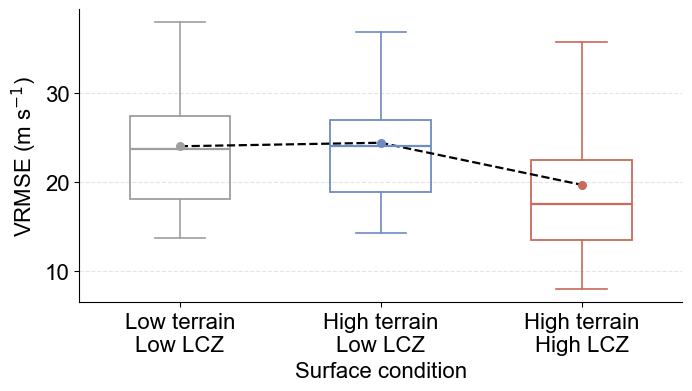

Mean VRMSE by case:
era5_no_lcz_no_srtm    24.053769
era5_no_lcz            24.449136
era5                   19.719558
Name: mean_vrmse, dtype: float64

Mean Δ (hi-terrain added): era5_no_lcz - era5_no_lcz_no_srtm = 0.3953664008701203
Mean Δ (hi-LCZ added):     era5 - era5_no_lcz = -4.7295780811614065

Saved figure: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish\vrmse_terrain_lcz_box_20250923-19_to_20250924-01_24h_era5_surface_cases.tif


WindowsPath('publish/vrmse_terrain_lcz_box_20250923-19_to_20250924-01_24h_era5_surface_cases.tif')

In [5]:
# ----------------------------------------------------------------------------
# Plot: 3-case boxplot + mean trend overlay (Fig4-style)
# ----------------------------------------------------------------------------

# Prepare data
case_labels = [CASE_META[k]["label"] for k in CASE_ORDER]
case_colors = [CASE_META[k]["color"] for k in CASE_ORDER]

case_values: list[np.ndarray] = []
means: list[float] = []

for k in CASE_ORDER:
    vals = (
        vrmse_long.loc[vrmse_long["case_key"] == k, "vrmse"]
        .astype(float)
        .dropna()
        .to_numpy()
    )
    case_values.append(vals)
    means.append(float(np.nanmean(vals)) if vals.size else np.nan)

positions = np.arange(len(CASE_ORDER), dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 4.2))

common_kwargs = dict(
    widths=0.50,
    patch_artist=True,
    showfliers=False,  # no outliers
    showmeans=True,
    meanline=False,
    boxprops=dict(linewidth=1.3),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    meanprops=dict(
        marker="o",
        markersize=5.5,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
    ),
)

bp = ax.boxplot(case_values, positions=positions, **common_kwargs)

# Color each case (hollow box, colored edges like Fig4)
for i, (color, box) in enumerate(zip(case_colors, bp.get("boxes", []))):
    box.set_facecolor("none")
    box.set_edgecolor(color)
    box.set_linewidth(1.3)

# Each box has 2 whiskers + 2 caps
for i, color in enumerate(case_colors):
    for artist in bp.get("whiskers", [])[2 * i : 2 * i + 2]:
        artist.set_color(color)
        artist.set_linewidth(1.2)
    for artist in bp.get("caps", [])[2 * i : 2 * i + 2]:
        artist.set_color(color)
        artist.set_linewidth(1.2)

# Median bars + mean dots match case color
for i, color in enumerate(case_colors):
    if i < len(bp.get("medians", [])):
        bp["medians"][i].set_color(color)
        bp["medians"][i].set_linewidth(1.6)
    if i < len(bp.get("means", [])):
        bp["means"][i].set_markerfacecolor(color)
        bp["means"][i].set_markeredgecolor(color)
        bp["means"][i].set_zorder(3)

# Trend overlay: connect mean points (no legend)
ax.plot(
    positions,
    means,
    color="black",
    linestyle="--",
    linewidth=1.6,
    zorder=2,
 )

ax.set_xticks(positions)
ax.set_xticklabels(case_labels)
ax.set_xlabel("Surface condition")
ax.set_ylabel("VRMSE (m s$^{-1}$)")

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

out_fig = OUT_DIR / f"vrmse_terrain_lcz_box_{WINDOW_TAG}_{LEAD}_era5_surface_cases.tif"
save_tiff(fig, out_fig, dpi=600)
plt.show()

# Print deltas for the trend (mean)
mean_series = pd.Series(means, index=CASE_ORDER, name="mean_vrmse")
delta_terrain = mean_series["era5_no_lcz"] - mean_series["era5_no_lcz_no_srtm"]
delta_lcz = mean_series["era5"] - mean_series["era5_no_lcz"]

print("Mean VRMSE by case:")
print(mean_series)
print("\nMean Δ (hi-terrain added): era5_no_lcz - era5_no_lcz_no_srtm =", float(delta_terrain))
print("Mean Δ (hi-LCZ added):     era5 - era5_no_lcz =", float(delta_lcz))

print("\nSaved figure:", out_fig.resolve())
out_fig